## Downloading data

In [1]:
# import kagglehub

# path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

# print("Path to dataset files:", path)

## Preprocessing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
)
# load dataset downloaded from kaggle
df = pd.read_csv("data/adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df["workclass"].value_counts()

Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: workclass, dtype: int64

In [6]:
# clean missing
df = df.replace("?", np.nan).dropna()

"?" is not a realistic value, if we keep them, the model will get confused.

## Define target col

In [7]:
TARGET_COL = "income"

In [8]:
# Convert income labels to binary 0 or 1
y = df[TARGET_COL].astype(str).str.contains(">50K").astype(int)

X = df.drop(columns=[TARGET_COL])

Define target column and seperate it with other input columns. We want to look at the person's info to predict if their income is either >50K or <=50K So we clean data and turn the target col into binary 0 and 1. A numeric prediction results is cleaner for metrics and consistency.

## Test/Train split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 80, 20 percent ratio
    random_state=42,
    stratify=y
)

Test and training data spliting into 70/30 ratio. Essential in ML model training. Test data must be seperate. 

## Preprocessing

In [10]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_cols),
        ("cat", categorical_preprocess, categorical_cols),
    ],
    remainder="drop"
)

Different kind of input columns needs different handle methods. One is numeric kind other is like words. For the missing values in the columns, numeric ones we just fill in the median of the column, what could have been done alternatively is to use average value or KNN imputation, and for missing values in the words columns we fill in the most commen value that appeared in the dataset. One hot encoder, why is it necessary, Decision trees need numbers, they can't split based on raw string values. The handle_unknow parameter is situatied when the test data has a new column that is never encountered in the training data, it will just ignore it. 

## Model pipeline

In [11]:
clf = DecisionTreeClassifier(random_state=42)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", clf)
])

to call the preprocess and train the model.
Decision Tree is like a game of 20 questions,
It repeatedly asks:

“Is age > 37.5?”

“Is education = Bachelors?”

“Is hours-per-week > 40?”

Each question splits people into two groups.
At the end (leaf), it outputs the majority class.

# How does it choose the “best” question?

It tries to make the groups as “pure” as possible.

That’s what Gini and Entropy measure: impurity.

# Gini impurity

If a node has 50/50 classes → high impurity

If a node is almost all one class → low impurity

The tree chooses the split that reduces impurity the most.

## Hyperparameter tuning (GridSearchCV)

In [12]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 10, 12, None],
    "model__min_samples_split": [2, 10, 50, 200],
    "model__min_samples_leaf": [1, 5, 20, 50],
    "model__ccp_alpha": [0.0, 0.0001, 0.001],  # cost-complexity pruning
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",        # Adult income is imbalanced-ish; F1 is usually better than accuracy
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['age',
                                                                          'fnlwgt',
                                                                          'educational-num',
                                                                          'capital-gain',
                                                                          'capital-loss',
                                                                          'hours-per-week']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(stra...
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'gender',
                                                                          'native-country'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__ccp_alpha': [0.0, 0.0001, 0.001],
                         'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [3, 5, 8, 10, 12, None],
                         'model__min_samples_leaf': [1, 5, 20, 50],
                         'model__min_samples_split': [2, 10, 50, 200]},
             scoring='f1', verbose=1)

Hyperparameter tuning with GridSearchCV
Tuning often improves performance and helps with avoiding overfitting problem. Alternatively RandomSearch or Bayesian optimization.

max_depth

“How many questions max?”

small depth = simple tree (may underfit)

big depth = complex tree (may overfit)

min_samples_split

“Don’t split a group unless it has at least this many people”
Helps stop silly splits on tiny groups.

min_samples_leaf

“Each final group must have at least this many people”
Again helps stop overfitting.

criterion (gini vs entropy)

Two ways to measure “messiness” in a node.

ccp_alpha

Pruning strength (cost-complexity pruning):
“Cut off small branches that don’t help much.”

Cross validation is also used, why?
cv=5 means:
Split training data into 5 parts:

train on 4 parts

validate on 1 part
Repeat so each part gets to be validation once.

instead of validating it once, we validate it 5 times so that it should be more fair.

We could increas the number of K for cv but it could be much slower.

In [13]:
print("\nBest parameters:")
print(grid.best_params_)
print("\nBest CV F1:")
print(grid.best_score_)


Best parameters:
{'model__ccp_alpha': 0.0001, 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 200}

Best CV F1:
0.6813624330858288


we choose F1 score over accuracy, in general sence adult income is not really balanced (more <=50K than >50K). So if a model just predict that everyone has a <50K income, the accuracy of that model won't be very low neither. 
F1-score focuses on the positive class quality

F1 balances:

Precision: “When I predict >50K, how often am I correct?”

Recall: “Out of real >50K people, how many did I find?”

In [14]:
best_model = grid.best_estimator_

## Evaluation on test set

In [15]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nTEST METRICS")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# Some ROC/AUC metrics require probabilities
# Decision trees support predict_proba by default
y_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC  : {auc:.4f}")


TEST METRICS
Accuracy: 0.8551
F1-score : 0.6803

Classification report:
              precision    recall  f1-score   support

           0     0.8821    0.9318    0.9063      6803
           1     0.7504    0.6222    0.6803      2242

    accuracy                         0.8551      9045
   macro avg     0.8163    0.7770    0.7933      9045
weighted avg     0.8495    0.8551    0.8503      9045

ROC-AUC  : 0.9018


ROC-AUC (Receiver Operating Characteristic Area Under the Curve), Instead of just saying “yes/no”, the model also says: “I’m 83% sure this person is >50K.”
ROC-AUC measures how well it ranks positives above negatives overall.

Why is it useful? ==> ROC-AUC is threshold-independent. Good if we later might choose different thresholds.

ROC Curve: Plots the True Positive Rate against the False Positive Rate at various thresholds.

AUC Interpretation:

1.0: Perfect model.

0.5: Random guessing (diagonal line).

< 0.5: Generally indicates poor model performance or inverted labels.

## Plots: Confusion matrix + ROC curve

<Figure size 640x480 with 0 Axes>

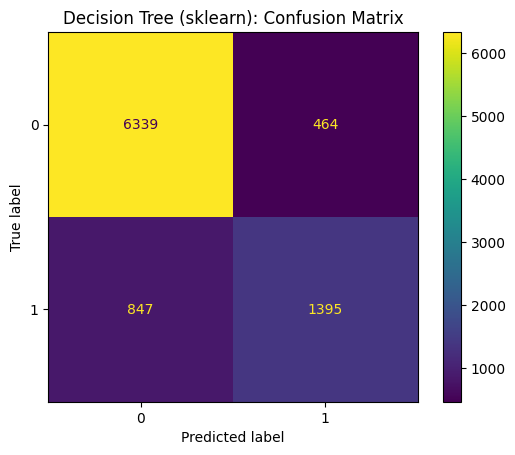

<Figure size 640x480 with 0 Axes>

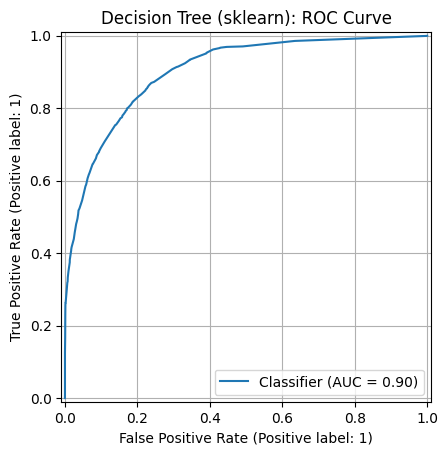

In [16]:
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format="d")
plt.title("Decision Tree (sklearn): Confusion Matrix")
plt.grid(False)
plt.savefig("sk_cm.png", bbox_inches="tight", dpi=200)
plt.show()

plt.figure()
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Decision Tree (sklearn): ROC Curve")
plt.grid(True)
plt.savefig("sk_roc.png", bbox_inches="tight", dpi=200)
plt.show()


Confusion matrix plot.

A 2×2 table:

True Positive: predicted >50K and correct

False Positive: predicted >50K but wrong

True Negative: predicted <=50K and correct

False Negative: predicted <=50K but wrong

It shows in general what kind of mistakes the model makes.

ROC(Receiver Operating Characteristic) curve plot

Shows tradeoff:

True Positive Rate vs False Positive Rate as threshold changes.

If we change how strict the model is, this shows how sensitivity and false alarms change.

## Plot: Feature importances (top 20)

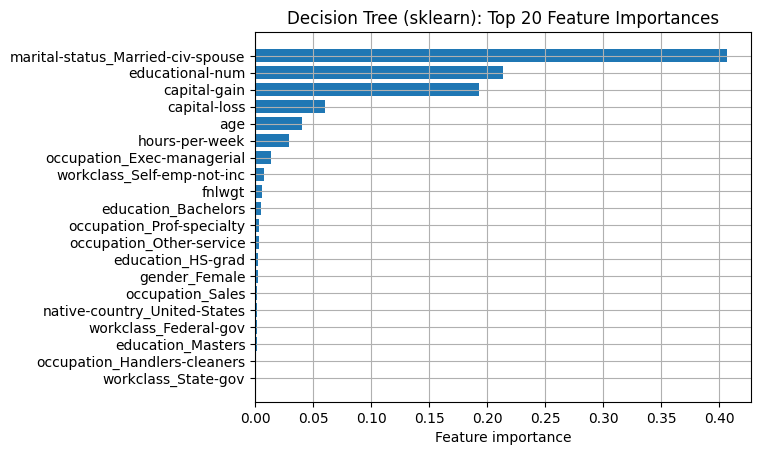

In [17]:
pre = best_model.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

# Numeric names + one-hot names
num_names = numeric_cols
cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
feature_names = num_names + cat_names

tree = best_model.named_steps["model"]
importances = tree.feature_importances_

# Safety: in rare cases, lengths can differ due to pipeline quirks; guard it
m = min(len(feature_names), len(importances))
feature_names = feature_names[:m]
importances = importances[:m]

top_k = 20
idx = np.argsort(importances)[-top_k:]

plt.figure()
plt.barh(np.array(feature_names)[idx], importances[idx])
plt.xlabel("Feature importance")
plt.title(f"Decision Tree (sklearn): Top {top_k} Feature Importances")
plt.grid(True)
plt.savefig("sk_feature_importance.png", bbox_inches="tight", dpi=200)
plt.show()

Decision trees can estimate which features were most useful for splitting.

It tells us which clues the tree used most when making decisions. Great for interpretation and report discussion.

## Plot: Learning curve (diagnose under/overfitting)

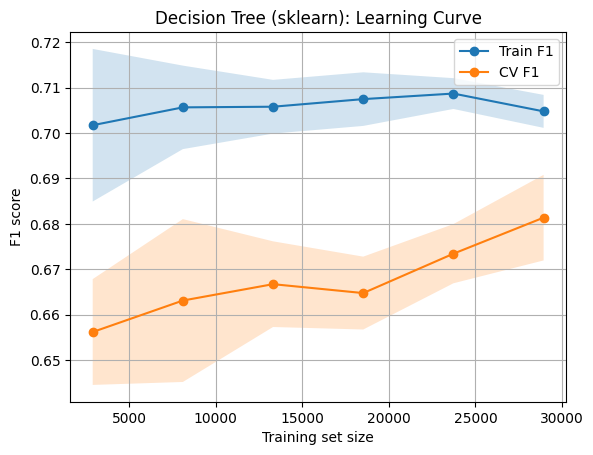

In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Train F1")
plt.plot(train_sizes, val_mean, marker="o", label="CV F1")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.title("Decision Tree (sklearn): Learning Curve")
plt.grid(True)
plt.legend()
plt.savefig("sk_learning_curve.png", bbox_inches="tight", dpi=200)
plt.show()

two lines of Training F1 score and CV F1 score, so basiclly we check if the model performs much better in Training set than Validation set, the answer here is no. Just 0.05 better ingeneral. So it's not overfitting. 

## Plot: CV results heatmap-like (simple 1D plot)

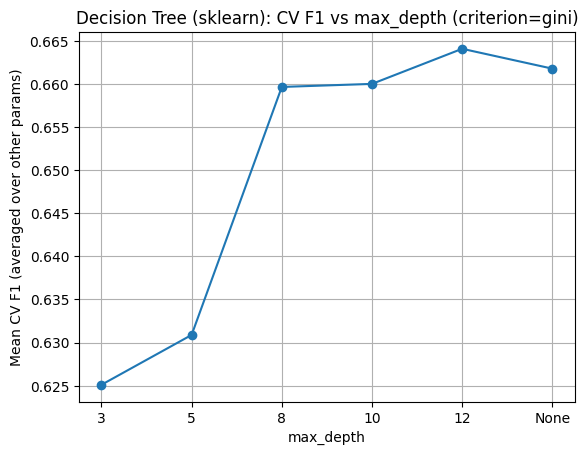

In [19]:
cv_results = pd.DataFrame(grid.cv_results_)

# Pick the best criterion to keep it readable
best_criterion = grid.best_params_["model__criterion"]
subset = cv_results[cv_results["param_model__criterion"] == best_criterion].copy()

# Convert max_depth None to string for plotting
subset["depth_str"] = subset["param_model__max_depth"].astype(str)

# Aggregate mean F1 by depth (averaging over other params)
agg = subset.groupby("depth_str")["mean_test_score"].mean().reset_index()
# Keep a sensible order
order = ["3", "5", "8", "10", "12", "None"]
agg["depth_str"] = pd.Categorical(agg["depth_str"], categories=order, ordered=True)
agg = agg.sort_values("depth_str")

plt.figure()
plt.plot(agg["depth_str"].astype(str), agg["mean_test_score"], marker="o")
plt.xlabel("max_depth")
plt.ylabel("Mean CV F1 (averaged over other params)")
plt.title(f"Decision Tree (sklearn): CV F1 vs max_depth (criterion={best_criterion})")
plt.grid(True)
plt.savefig("sk_cv_f1_vs_depth.png", bbox_inches="tight", dpi=200)
plt.show()

We summarize GridSearch results to see how depth affects performance on average. It's like “How many questions should the tree be allowed to ask?” 

## Numpy Tree Implementation

In [20]:
import numpy as np

class _Node:
    __slots__ = ("feature", "threshold", "left", "right", "is_leaf","proba", "pred")
    def __init__(self, *, feature=None, threshold=None, left=None, right=None,
                 is_leaf=False, proba=None, pred=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.is_leaf = is_leaf
        self.proba = proba
        self.pred = pred


In [25]:
class NumpyTreeClassifier:
    """
    A NumPy-only decision tree for classification.
    """
    def __init__(self, criterion="gini", max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, min_gain = 0.0, random_state=None):
        
        # Values will be inherited from gridsearch results.

        if criterion not in ("gini", "entropy"):
            raise ValueError("criterion must be either 'gini' or 'entropy'")
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = int(min_samples_split)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_gain = float(min_gain)
        self.random_state = random_state

        self.classes_ = None
        self.n_classes_ = None
        self.root_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_, y_enc = np.unique(y, return_inverse=True)
        self.n_classes_ = len(self.classes_)

        self.root_ = self._grow(X, y_enc, depth=0) 

        return self

    def predict(self, X):
        X = np.asarray(X)
        preds_enc = np.array([self._predict_one(x, self.root_) for x in X], dtype=int)
        return self.classes_[preds_enc]

    def predict_proba(self, X):
        X = np.asarray(X)
        out = np.zeros((X.shape[0], self.n_classes_), dtype=float)
        for i, x in enumerate(X):
            node = self.root_
            while not node.is_leaf:
                if x[node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            out[i] = node.proba
        return out

    # ---------- internals ----------
    def _impurity_from_counts(self, counts):
        n = counts.sum()
        if n <= 0:
            return 0.0
        p = counts / n
        if self.criterion == "gini":
            return 1.0 - np.sum(p * p)
        # entropy
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    def _best_split(self, X, y):
        n, d = X.shape
        if n < self.min_samples_split:
            return None, None, None

        parent_counts = np.bincount(y, minlength=self.n_classes_)
        parent_impurity = self._impurity_from_counts(parent_counts)
        if parent_impurity == 0.0:
            return None, None, None

        best_gain = 0.0
        best_feat = None
        best_thr = None
        best_mask = None

        for j in range(d):
            xj = X[:, j]

            # Sort samples by this feature
            order = np.argsort(xj, kind="quicksort")
            x_sorted = xj[order]
            y_sorted = y[order]

            # If feature is constant -> skip
            if x_sorted[0] == x_sorted[-1]:
                continue

            left_counts = np.zeros(self.n_classes_, dtype=int)
            right_counts = parent_counts.copy()

            # Consider split points between distinct feature values
            # We'll update counts incrementally as we move the split.
            for i in range(0, n - 1):
                c = y_sorted[i]
                left_counts[c] += 1
                right_counts[c] -= 1

                # Ensure both sides meet min_samples_leaf
                left_n = i + 1
                right_n = n - left_n
                if left_n < self.min_samples_leaf or right_n < self.min_samples_leaf:
                    continue

                # Only split if next value differs (valid threshold between)
                if x_sorted[i] == x_sorted[i + 1]:
                    continue

                left_imp = self._impurity_from_counts(left_counts)
                right_imp = self._impurity_from_counts(right_counts)

                # Information gain
                weighted = (left_n / n) * left_imp + (right_n / n) * right_imp
                gain = parent_impurity - weighted

                if gain > best_gain:
                    best_gain = gain
                    best_feat = j
                    best_thr = 0.5 * (x_sorted[i] + x_sorted[i + 1])

        # "Easy pruning": require minimum gain to split
        if best_feat is None or best_gain <= self.min_gain:
            return None, None, None

        mask = X[:, best_feat] <= best_thr
        return best_feat, best_thr, mask

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.n_classes_)
        n = y.size
        proba = counts / n
        pred = int(np.argmax(counts))

        impurity = self._impurity_from_counts(counts)

        if (self.max_depth is not None and depth >= self.max_depth) or \
           n < self.min_samples_split or \
           impurity == 0.0:
            return _Node(is_leaf=True, proba=proba, pred=pred)

        feat, thr, mask = self._best_split(X, y)
        if feat is None:
            return _Node(is_leaf=True, proba=proba, pred=pred)

        left = self._grow(X[mask], y[mask], depth + 1)
        right = self._grow(X[~mask], y[~mask], depth + 1)
        return _Node(feature=feat, threshold=thr, left=left, right=right,
                     is_leaf=False, proba=proba, pred=pred)

    def _predict_one(self, x, node):
        while not node.is_leaf:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.pred

In [26]:
pre = best_model.named_steps["preprocess"]  # already fitted

Xtr = pre.transform(X_train)
Xte = pre.transform(X_test)

In [27]:
# OneHotEncoder often outputs sparse matrices -> convert to dense NumPy
Xtr = Xtr.toarray() if hasattr(Xtr, "toarray") else np.asarray(Xtr)
Xte = Xte.toarray() if hasattr(Xte, "toarray") else np.asarray(Xte)

In [28]:
ntree = NumpyTreeClassifier(
    criterion=grid.best_params_["model__criterion"],
    max_depth=grid.best_params_["model__max_depth"],
    min_samples_split=grid.best_params_["model__min_samples_split"],
    min_samples_leaf=grid.best_params_["model__min_samples_leaf"],
    min_gain=grid.best_params_["model__ccp_alpha"],
    random_state=42
)
ntree.fit(Xtr, y_train)

In [ ]:
pred = ntree.predict(Xte)

print("Accuracy:", accuracy_score(y_test, pred))

# If binary labels are strings, pick the positive label safely:
labels = np.unique(y_test)
pos_label = labels[-1] 
print("F1:", f1_score(y_test, pred, pos_label=pos_label))

Accuracy: 0.8512990602542841
F1: 0.676760394136025


In [32]:
proba = ntree.predict_proba(Xte)

In [33]:
sk_pred = y_pred
sk_proba = y_proba

np_pred = pred
np_proba = proba

# ----------------------------
# Metrics table
# ----------------------------

In [34]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

In [36]:
def compute_metrics(y_true, y_pred, pos_label=None):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)

    if pos_label is not None:
        out["f1"] = f1_score(y_true, y_pred, pos_label=pos_label)
        out["precision"] = precision_score(y_true, y_pred, pos_label=pos_label)
        out["recall"] = recall_score(y_true, y_pred, pos_label=pos_label)
    else:
        # multiclass: use macro averaging
        out["f1"] = f1_score(y_true, y_pred, average="macro")
        out["precision"] = precision_score(y_true, y_pred, average="macro")
        out["recall"] = recall_score(y_true, y_pred, average="macro")
    return out

sk_metrics = compute_metrics(y_test, sk_pred, pos_label=pos_label)
np_metrics = compute_metrics(y_test, np_pred, pos_label=pos_label)

print("Sklearn tree metrics:", sk_metrics)
print("NumPy tree metrics:  ", np_metrics)

Sklearn tree metrics: {'accuracy': 0.8550580431177446, 'f1': 0.6803218727139722, 'precision': 0.750403442711135, 'recall': 0.6222123104371097}
NumPy tree metrics:   {'accuracy': 0.8512990602542841, 'f1': 0.676760394136025, 'precision': 0.7337154768108389, 'recall': 0.6280107047279215}


# ----------------------------
# Metric comparison bar plot
# ----------------------------

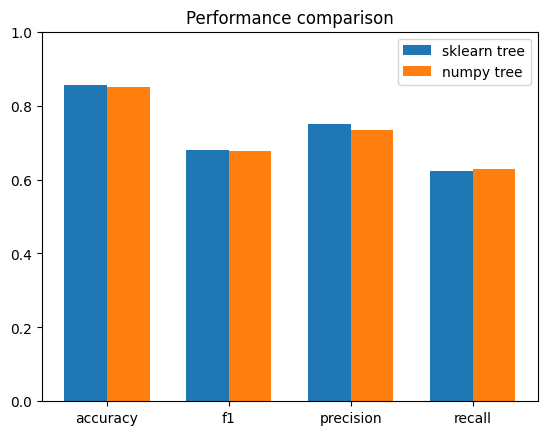

In [37]:
metric_names = ["accuracy", "f1", "precision", "recall"]
sk_vals = [sk_metrics[m] for m in metric_names]
np_vals = [np_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

plt.figure()
plt.bar(x - width/2, sk_vals, width, label="sklearn tree")
plt.bar(x + width/2, np_vals, width, label="numpy tree")
plt.xticks(x, metric_names)
plt.ylim(0, 1.0)
plt.title("Performance comparison")
plt.legend()
plt.show()


# ----------------------------
# Confusion matrices (side-by-side)
# ----------------------------

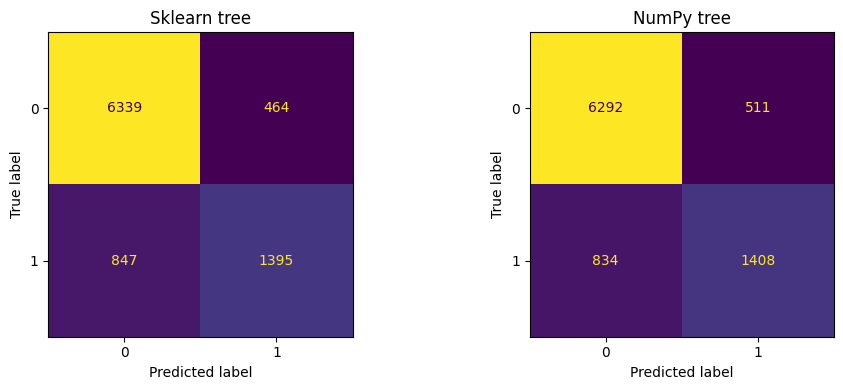

In [38]:
cm_sk = confusion_matrix(y_test, sk_pred, labels=labels)
cm_np = confusion_matrix(y_test, np_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_sk, display_labels=labels).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Sklearn tree")

ConfusionMatrixDisplay(cm_np, display_labels=labels).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("NumPy tree")

plt.tight_layout()
plt.show()


# ----------------------------
# ROC + PR curves
# ----------------------------

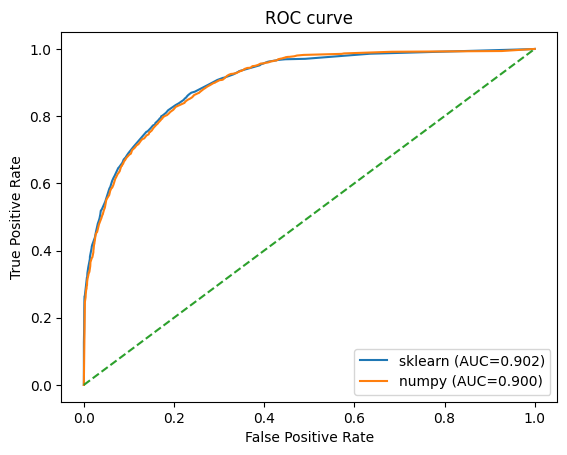

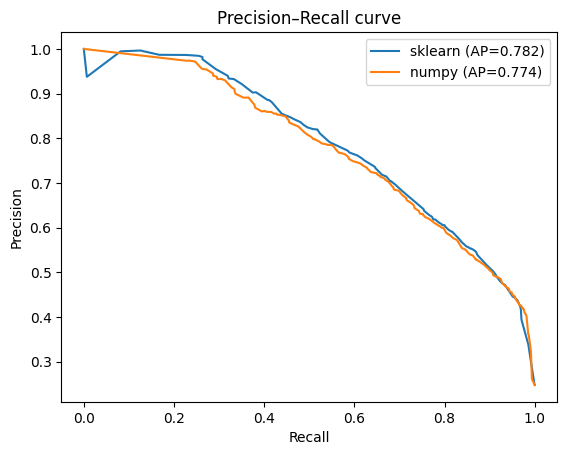

In [47]:
def proba_for_pos(proba, classes, pos_label, assume_pos_index=1):
    """
    Return a 1D array of scores for the positive class.

    - If proba is 2D (n_samples, n_classes): return the column matching pos_label.
    - If proba is 1D (n_samples,): assume it already represents P(pos_label).
      (common when you do predict_proba(...)[:, 1])
    """
    proba = np.asarray(proba)

    # Case 1: already a 1D vector of positive-class probabilities/scores
    if proba.ndim == 1:
        return proba

    # Case 2: normal predict_proba matrix
    if proba.ndim == 2:
        # If we can map by label, do it
        if classes is not None:
            classes = np.asarray(classes)
            idx = np.where(classes == pos_label)[0]
            if idx.size == 1:
                return proba[:, int(idx[0])]

        # Fallback: assume positive is column 1
        if proba.shape[1] <= assume_pos_index:
            raise ValueError(f"proba has shape {proba.shape}, can't take column {assume_pos_index}.")
        return proba[:, assume_pos_index]

    raise ValueError(f"Unexpected proba shape: {proba.shape}")

# sklearn classes (from final estimator in pipeline)
sk_classes = best_model.named_steps["model"].classes_
np_classes = ntree.classes_

y_true_bin = (np.asarray(y_test) == pos_label).astype(int)

sk_pos = proba_for_pos(sk_proba, sk_classes, pos_label)
np_pos = proba_for_pos(np_proba, np_classes, pos_label)

# ROC
fpr_sk, tpr_sk, _ = roc_curve(y_true_bin, sk_pos)
fpr_np, tpr_np, _ = roc_curve(y_true_bin, np_pos)

auc_sk = auc(fpr_sk, tpr_sk)
auc_np = auc(fpr_np, tpr_np)

plt.figure()
plt.plot(fpr_sk, tpr_sk, label=f"sklearn (AUC={auc_sk:.3f})")
plt.plot(fpr_np, tpr_np, label=f"numpy (AUC={auc_np:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

# Precision-Recall
prec_sk, rec_sk, _ = precision_recall_curve(y_true_bin, sk_pos)
prec_np, rec_np, _ = precision_recall_curve(y_true_bin, np_pos)

ap_sk = average_precision_score(y_true_bin, sk_pos)
ap_np = average_precision_score(y_true_bin, np_pos)

plt.figure()
plt.plot(rec_sk, prec_sk, label=f"sklearn (AP={ap_sk:.3f})")
plt.plot(rec_np, prec_np, label=f"numpy (AP={ap_np:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve")
plt.legend()
plt.show()


# ----------------------------
# Tree complexity comparison (depth + node count)
# ----------------------------

Sklearn tree: nodes=213, depth=21
NumPy tree:   nodes=801, depth=31


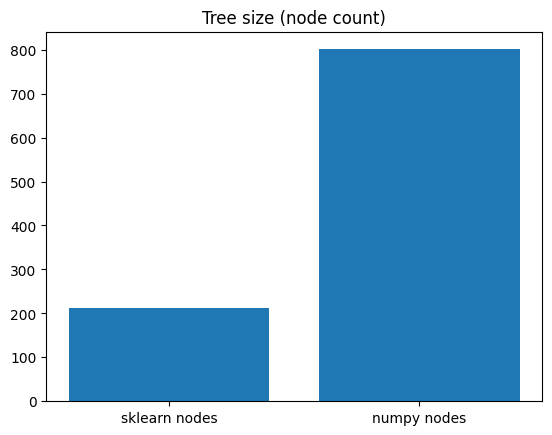

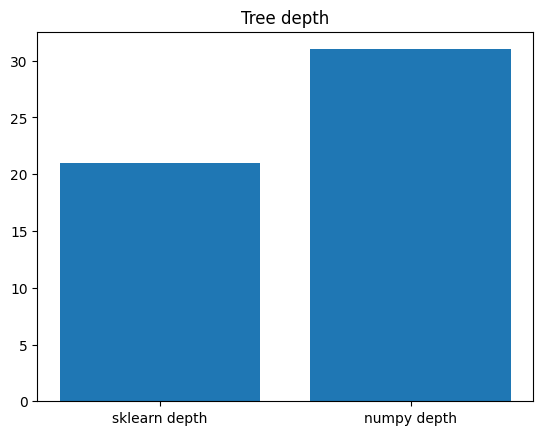

In [50]:
# sklearn tree stats
sk_tree = best_model.named_steps["model"].tree_
sk_node_count = sk_tree.node_count
sk_depth = best_model.named_steps["model"].get_depth()

# numpy tree stats (helpers)
def numpy_tree_node_count(node):
    if node is None:
        return 0
    if node.is_leaf:
        return 1
    return 1 + numpy_tree_node_count(node.left) + numpy_tree_node_count(node.right)

def numpy_tree_depth(node):
    if node is None:
        return 0
    if node.is_leaf:
        return 1
    return 1 + max(numpy_tree_depth(node.left), numpy_tree_depth(node.right))

np_node_count = numpy_tree_node_count(ntree.root_)
np_depth = numpy_tree_depth(ntree.root_)

print(f"Sklearn tree: nodes={sk_node_count}, depth={sk_depth}")
print(f"NumPy tree:   nodes={np_node_count}, depth={np_depth}")

plt.figure()
plt.bar(["sklearn nodes", "numpy nodes"], [sk_node_count, np_node_count])
plt.title("Tree size (node count)")
plt.show()

plt.figure()
plt.bar(["sklearn depth", "numpy depth"], [sk_depth, np_depth])
plt.title("Tree depth")
plt.show()